# Time height cross sections
Applies 6 hourly QTRACK data and interpolates the track to 3 hours, to match each ensemble member. 

Applies simple linear interpolation from A. Aiyyer between data points.

Can plot a time-height composite following the wave center for each ensemble set, whether control, fluxoff, rst_on24, rst_on36, rst_on48.

In [1]:
import pkg_resources
from __future__ import print_function
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
import os
import glob
from netCDF4 import Dataset, num2date, date2num

from AEW_module import season, AEW, AEW_CCKW

from metpy.units import units
import geocat.viz as gv


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker 

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import wrf
from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)

import seaborn as sns
import metpy.calc as mpcalc

/glade/derecho/scratch/athornton/tmp/ipykernel_17655/3015031533.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', '']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [3]:
# for compositing...
# Earliest time that all runs contain 
all_start_times = ['2020-09-04 00:00',  # fluxon
                   '2020-09-05 00:00',  # rst_on24
                   '2020-09-05 12:00',  # rst_on36
                   '2020-09-06 00:00',  # rst_on48
                   '',        
                   '2020-09-04 00:00',  # fluxoff
                   '',
                   '',
                   '']

In [4]:
### Pick ensemble set 
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[1]     # try: variation[2]
all_start_time = pd.to_datetime(all_start_times[1])
wave = 'second'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot

In [5]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [93]:
# From Anantha...
# Simple linear interpolation between each latitude point
def get_lats():
    new_lats = []
    wave_track_lats = df.lat[-len(times_list):]
    for i in range(0,len(wave_track_lats)):
        if wave_track_lats[i] == wave_track_lats[-1]:
            new_lats.append(wave_track_lats[i].values)
        else:
            next_value = 0.5*(wave_track_lats[i] + wave_track_lats[i+1])
            new_lats.append(wave_track_lats[i].values)
            new_lats.append(next_value.values)
    return new_lats

In [94]:
# From Anantha...
# Simple linear interpolation between each longitude point
def get_lons():
    new_lons = []
    wave_track_lons = df.lon[-len(times_list):] 
    for i in range(0,len(wave_track_lons)):
        if wave_track_lons[i] == wave_track_lons[-1]:
            new_lons.append(wave_track_lons[i].values)
        else:
            next_value = 0.5*(wave_track_lons[i] + wave_track_lons[i+1])
            new_lons.append(wave_track_lons[i].values)
            new_lons.append(next_value.values)
    return new_lons

In [105]:
# Empty list to put each initialization time's vorticity timeseries
vort_slice_list = []
for ens in init_times:
    save_name = set_name +"_"+ ens
    print(save_name)
    # Get track data
    start_time ='2020-09-'+ens[:2]+' '+ens[2:]+':00'

    # QTRACK data ends on the 9th for odd ens members
    if int(ens) % 2 == 0:
        end_time = '2020-09-09 12:00'
        print('even ens member. ending at 12z')
    else:
        end_time = '2020-09-09 09:00'
        print('odd ens member. ending at 09z')
    
    # This is for the QTRACK data
    times_list = pd.date_range(start=start_time, end=end_time, freq='6h') # Our QTRACK data is 6hrly
    df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+save_name+'.nc')
    # Interpolate lats and lons to 3 hours
    wave_track_lats = get_lats()
    wave_track_lons = get_lons()

    # Get wrf data
    os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+ens+"z/"+set_name+"/")
    datafiles = sorted(glob.glob("./wrfout*"))
    numfiles=len(datafiles)
    print(numfiles)
    print(datafiles[0])
        
    wrf_out_data = xr.open_dataset(datafiles[0])  
    p =wrf_out_data['P']

    # Empty list to put one timeseries of vorticity
    time_series_vo = []
    for i in range(0,len(wave_track_lats)):
        
        ncfile = Dataset(datafiles[i])
        Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
        timestr=(str(Time))
        # Set up one time string for plot titles, another for file names
        titletime=(timestr[0:10]+' '+timestr[11:16])
        filetime=(timestr[0:10]+'_'+timestr[11:16])
        print('WRF valid time: ',filetime)

        # If our file time is less than our common start time, 
        # we will skip this file, so our composites are the same length
        delta_t = pd.Timedelta(Time - all_start_time).total_seconds() 
        if delta_t < 0.0:
            print('skipping this datafile')
            pass
        else:
            print('using this datafile')
        
            wrf_out_data = xr.open_dataset(datafiles[i])  
            
            # Get sea level pressure and wind variables
            ua = wrf_out_data["U"]
            va = wrf_out_data["V"]
            p  = wrf_out_data["P"]
            pb = wrf_out_data["PB"]
            
            # Unstagger the winds to match the pressure grid
            ua = destagger(ua, stagger_dim=3)  # Unstagger U in the x-direction
            va = destagger(va, stagger_dim=2)  # Unstagger V in the x-direction
            
            # Grid spacing for vorticity calculation
            dx = ncfile.DX * units("m")
            dy = ncfile.DY * units("m")
            
            u_winds = xr.DataArray(ua)*units("m/s") # attach units
            v_winds = xr.DataArray(va)*units("m/s") # attach units
            pres    = xr.DataArray(p)
            pb      = xr.DataArray(pb)
            lats, lons = latlon_coords(wrf_out_data['P'])
            lats_np = to_np(lats)
            lons_np = to_np(lons)
            u_winds = u_winds[0]
            v_winds = v_winds[0]
            pres = pres[0]
            pb = pb[0,:,0,0]
            pb = pb.metpy.convert_units('mbar')

            # Pick how much grid points east and west, north and south
            # of our center coordinate to average across
            delta = 11 # this will be 9 km x 22 = about 200 km zonally and meridonally
            
            # Lat, Lon cooridante of center of square we are interested in
            lat_lon = [wave_track_lats[i],wave_track_lons[i]]                 
            x_ycenter = wrf.ll_to_xy(ncfile, lat_lon[0], lat_lon[1])

            vo = mpcalc.vorticity(u_winds, v_winds, dx=dx, dy=dy)
            vert_slice_vo = vo[:,int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean(dim={'dim_2','dim_3'})            
            time_series_vo.append(vert_slice_vo)
    # Odd QTRACK ens members end on the 9th
    # this end time corresponds to the track data
    if int(ens) % 2 == 0:
        vort_slice_list.append(time_series_vo[:-1])
        print('even ens member. dropping 12z value')
    else:
        vort_slice_list.append(time_series_vo)
        print('odd ens member. appending full time series')
    

rst_on24_0300
even ens member. ending at 12z
53
./wrfout_d01_2020-09-03_00:00:00
WRF valid time:  2020-09-03_00:00
skipping this datafile
WRF valid time:  2020-09-03_03:00
skipping this datafile
WRF valid time:  2020-09-03_06:00
skipping this datafile
WRF valid time:  2020-09-03_09:00
skipping this datafile
WRF valid time:  2020-09-03_12:00
skipping this datafile
WRF valid time:  2020-09-03_15:00
skipping this datafile
WRF valid time:  2020-09-03_18:00
skipping this datafile
WRF valid time:  2020-09-03_21:00
skipping this datafile
WRF valid time:  2020-09-04_00:00
skipping this datafile
WRF valid time:  2020-09-04_03:00
skipping this datafile
WRF valid time:  2020-09-04_06:00
skipping this datafile
WRF valid time:  2020-09-04_09:00
skipping this datafile
WRF valid time:  2020-09-04_12:00
skipping this datafile
WRF valid time:  2020-09-04_15:00
skipping this datafile
WRF valid time:  2020-09-04_18:00
skipping this datafile
WRF valid time:  2020-09-04_21:00
skipping this datafile
WRF val

/glade/derecho/scratch/athornton/tmp/ipykernel_17655/41108831.py:92: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds, v_winds, dx=dx, dy=dy)


WRF valid time:  2020-09-05_03:00
using this datafile


/glade/derecho/scratch/athornton/tmp/ipykernel_17655/41108831.py:92: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds, v_winds, dx=dx, dy=dy)


WRF valid time:  2020-09-05_06:00
using this datafile


...

WRF valid time:  2020-09-09_09:00
using this datafile


/glade/derecho/scratch/athornton/tmp/ipykernel_17655/41108831.py:92: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds, v_winds, dx=dx, dy=dy)


WRF valid time:  2020-09-09_12:00
using this datafile


/glade/derecho/scratch/athornton/tmp/ipykernel_17655/41108831.py:92: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds, v_winds, dx=dx, dy=dy)


even ens member. dropping 12z value


In [109]:
common_times = pd.date_range(start=all_start_time, end='2020-09-09 09:00', freq='3h')

In [110]:
# convert our list of lists to an array
f = np.array(vort_slice_list)
vorticity = f.mean(axis=0)

Text(1.0, 1.0, 'Ensemble Set: rst_on24')

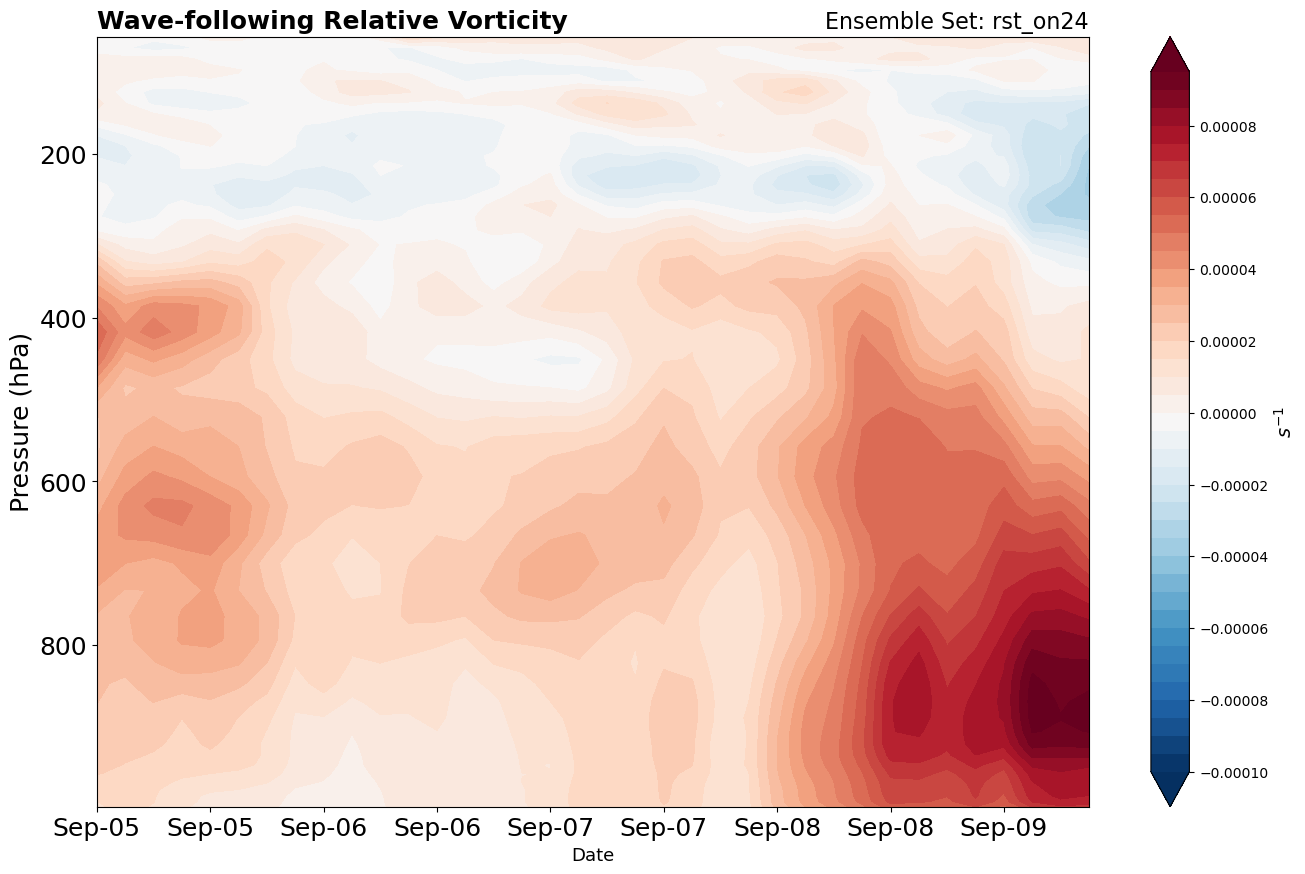

In [111]:
# Fig quality
plt.rcParams['savefig.dpi'] = 255

fig = plt.figure(figsize=(16,10))
ax = plt.axes()
plt.gca().invert_yaxis()
#levels = np.arange(-0.0005, 0.0005, 0.00005)
levels = np.arange(-0.0001, 0.0001, 0.000005)
cf = ax.contourf(common_times, pb, vorticity.T, levels=levels, cmap='RdBu_r', extend='both')
cb = plt.colorbar(cf)
cb.set_label('$s^{-1}$', fontsize=14)

#levels = np.arange(0.0015, 0.0150, 0.0025)
#cs = ax.contour(lon_slice, pb, moist, cmap='Greys_r')
#ax.clabel(cs, inline=True, fontsize=10)

levels2 = [-3, -1.5, 1.5, 3]
#cs2 = ax.contour(lon_slice, pb, v, colors='black', levels=levels2, linewidths=1.6)

ax.set_xlabel('Date', size=13)
date_form = DateFormatter('%b-%d')
ax.xaxis.set_major_formatter(date_form)

ax.set_ylabel('Pressure (hPa)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
#plt.yscale("log")
plt.title('Wave-following Relative Vorticity', loc='left', weight='bold', fontsize=18)
plt.title('Ensemble Set: '+str(set_name),
          loc='right', fontsize=16)
#plt.savefig(plotsdir+'time_height_vort_'+set_name+'.png')